# TPCC Comparison: dbfs vs PostgreSQL

This notebook compares two BenchBase TPCC runs collected under the same nominal settings and grouped under a shared comparison label:

- comparison label: `20260503`
- artifact selection: latest BenchBase artifact prefix under each engine directory
- dbfs result directory: `benchmarking/results/20260503/tpcc/dbfs`
- PostgreSQL result directory: `benchmarking/results/20260503/tpcc/postgres`

The notebook reads summary, metrics, params, samples, results, raw traces, per-procedure result windows, and optional query-trace CSVs from those directories to build side-by-side comparison tables and performance plots.

In [1]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use('ggplot')
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')

comparison_root = Path(
    '/Users/yohasebe/Documents/dbfs/benchmarking/results/20260603-145738/tpcc')

# Query trace viewer (early stage - works without metrics.json)
# 最新のベンチマーク結果から dbfs_query_trace.csv を探して表示

results_root = Path('/Users/yohasebe/Documents/dbfs/benchmarking/results')

# 最新のタイムスタンプディレクトリを探す
latest_timestamp = None
latest_trace_path = None

for timestamp_dir in sorted(results_root.glob('**/tpcc/dbfs'), reverse=True):
    trace_path = timestamp_dir / 'dbfs_query_trace.csv'
    if trace_path.exists():
        latest_timestamp = timestamp_dir.parent.parent.name
        latest_trace_path = trace_path
        break

if latest_trace_path:
    print(f"Loading query trace from: {latest_trace_path}")
    query_trace_df = pd.read_csv(latest_trace_path)

    # total_elapsed_us で降順ソート
    query_trace_sorted = query_trace_df.sort_values('total_elapsed_us',
                                                    ascending=False)

    # usをmsに変換して見やすく
    display_df = query_trace_sorted.copy()
    display_df['total_elapsed_ms'] = display_df['total_elapsed_us'] / 1000
    display_df['mean_elapsed_ms'] = display_df['mean_elapsed_us'] / 1000
    display_df['max_elapsed_ms'] = display_df['max_elapsed_us'] / 1000

    display(display_df[[
        'kind', 'shape_key', 'executions', 'total_elapsed_ms',
        'mean_elapsed_ms', 'max_elapsed_ms', 'failures', 'last_error_type'
    ]])
else:
    print("No dbfs_query_trace.csv found in recent results")


Loading query trace from: /Users/yohasebe/Documents/dbfs/benchmarking/results/20260603-145738/tpcc/dbfs/dbfs_query_trace.csv


,kind,shape_key,executions,total_elapsed_ms,mean_elapsed_ms,max_elapsed_ms,failures,last_error_type
0,QUERY,"SELECT S_QUANTITY, S_DATA, S_DIST_01, S_DIST_0...",5330,"10,606.688",1.989,76.822,0,NaN
1,QUERY,"SELECT I_PRICE, I_NAME , I_DATA FROM item WHER...",5333,"10,215.521",1.915,262.683,0,NaN
2,UPDATE,"UPDATE stock SET S_QUANTITY = ? , S_YTD = S_YT...",5304,"6,781.967",1.278,39.346,0,NaN
3,UPDATE,"INSERT INTO order_line (OL_O_ID, OL_D_ID, OL_W...",5304,"4,868.486",0.917,126.820,0,NaN
4,QUERY,"SELECT C_FIRST, C_MIDDLE, C_ID, C_STREET_1, C_...",335,"4,206.377",12.556,151.149,0,NaN
5,QUERY,SELECT NO_O_ID FROM new_order WHERE NO_D_ID = ...,580,"1,719.955",2.965,75.057,0,NaN
6,UPDATE,UPDATE warehouse SET W_YTD = W_YTD + ? WHERE W...,497,"1,304.946",2.625,643.469,0,NaN
7,QUERY,"SELECT C_DISCOUNT, C_LAST, C_CREDIT FROM custo...",529,"1,228.892",2.323,37.333,0,NaN
8,UPDATE,UPDATE order_line SET OL_DELIVERY_D = ? WHERE ...,580,"1,194.305",2.059,39.708,0,NaN
9,QUERY,SELECT SUM(OL_AMOUNT) AS OL_TOTAL FROM order_l...,580,"1,104.789",1.904,23.172,0,NaN


In [2]:
run_configs = {
    'dbfs': {
        'label': 'tpcc_2026-05-22_06-34-29',
        'display_name': 'dbfs',
        'result_dir': comparison_root / 'dbfs',
    },
    'postgres': {
        'label': 'tpcc_2026-05-22_06-34-29',
        'display_name': 'PostgreSQL',
        'result_dir': comparison_root / 'postgres',
    },
}

configured_ratios = pd.Series(
    {
        'NewOrder': 45.0,
        'Payment': 43.0,
        'OrderStatus': 4.0,
        'Delivery': 4.0,
        'StockLevel': 4.0,
    },
    name='Configured Ratio (%)')

required_suffixes = {
    'summary': '.summary.json',
    'metrics': '.metrics.json',
    'params': '.params.json',
    'results': '.results.csv',
    'samples': '.samples.csv',
    'raw': '.raw.csv',
}

query_trace_filenames = {
    'dbfs': 'dbfs_query_trace.csv',
    'postgres': 'postgres_query_trace.csv',
}
procedure_suffix = '.results.'

In [3]:
def load_terminal_log(result_dir):
    for filename in [
            'benchbase.log', 'benchbase_setup.log', 'benchbase_execute.log'
    ]:
        path = result_dir / filename
        if path.exists():
            return path.read_text(encoding='utf-8')
    return ''


run_configs['dbfs']['terminal_log'] = load_terminal_log(
    run_configs['dbfs']['result_dir'])
run_configs['postgres']['terminal_log'] = load_terminal_log(
    run_configs['postgres']['result_dir'])

field_patterns = {
    'workload': re.compile(r'Benchmark:\s+(\w+)'),
    'dbms_type': re.compile(r'Type:\s+(\w+)'),
    'driver': re.compile(r'Driver:\s+(.+)'),
    'url': re.compile(r'URL:\s+(.+)'),
    'isolation': re.compile(r'Isolation:\s+(\S+)'),
    'loader_threads': re.compile(r'Loader Threads:\s+(\d+)'),
    'scale_factor': re.compile(r'Scale Factor:\s+([\d.]+)'),
    'terminals': re.compile(r'Terminals:\s+(\d+)'),
}
phase_pattern = re.compile(
    r'PHASE START :: .*\[Time=(\d+)\] \[WarmupTime=(\d+)\] \[Rate=([\d.]+)\].*\[Ratios=\[([^\]]+)\]\]'
)
rate_pattern = re.compile(
    r'measuredRequests=(\d+)\) = ([\d.]+) requests/sec \(throughput\), ([\d.]+) requests/sec \(goodput\)'
)


def parse_terminal_log(log_text):
    parsed = {}
    for key, pattern in field_patterns.items():
        match = pattern.search(log_text)
        parsed[key] = match.group(1).strip() if match else None

    phase_match = phase_pattern.search(log_text)
    if phase_match:
        parsed['phase_time_seconds'] = int(phase_match.group(1))
        parsed['warmup_time_seconds'] = int(phase_match.group(2))
        parsed['target_rate'] = float(phase_match.group(3))
        parsed['configured_ratio_list'] = [
            float(value.strip()) for value in phase_match.group(4).split(',')
        ]

    rate_match = rate_pattern.search(log_text)
    if rate_match:
        parsed['terminal_measured_requests'] = int(rate_match.group(1))
        parsed['terminal_throughput'] = float(rate_match.group(2))
        parsed['terminal_goodput'] = float(rate_match.group(3))

    return parsed


parsed_configs = pd.DataFrame([{
    'engine': engine,
    **parse_terminal_log(config['terminal_log'])
} for engine, config in run_configs.items()])
parsed_configs

,engine,workload,dbms_type,driver,url,isolation,loader_threads,scale_factor,terminals,terminal_measured_requests,terminal_throughput,terminal_goodput
0,dbfs,TPCC,POSTGRES,dev.yohaku.dbfs.jdbc.DbfsDriver,jdbc:dbfs://dbfs:25432/benchbase,TRANSACTION_SERIALIZABLE,2,1.0,1,NaN,NaN,NaN
1,postgres,TPCC,POSTGRES,dev.yohaku.dbfs.jdbc.TracingPostgresDriver,jdbc:trace:postgresql://postgres:5432/benchbas...,TRANSACTION_SERIALIZABLE,2,1.0,1,"21,469.000",357.816,355.866


In [4]:
def find_latest_artifact_prefix(result_dir):
    summary_suffix = required_suffixes['summary']
    matches = sorted(result_dir.glob(f'*{summary_suffix}'))
    if not matches:
        raise FileNotFoundError(
            f'No artifact ending with {summary_suffix} under {result_dir}')
    latest_summary = matches[-1]
    return latest_summary.name[:-len(summary_suffix)]


def find_artifact(result_dir, run_label, suffix):
    artifact_path = result_dir / f'{run_label}{suffix}'
    if not artifact_path.exists():
        raise FileNotFoundError(
            f'No artifact ending with {suffix} for {run_label} under {result_dir}'
        )
    return artifact_path


def load_optional_query_trace(engine, result_dir):
    trace_path = result_dir / query_trace_filenames[engine]
    if not trace_path.exists():
        return trace_path, None
    return trace_path, pd.read_csv(trace_path)


def load_run_artifacts(engine, config):
    result_dir = config['result_dir']
    detected_label = find_latest_artifact_prefix(result_dir)
    artifacts = {
        name: find_artifact(result_dir, detected_label, suffix)
        for name, suffix in required_suffixes.items()
    }
    procedure_paths = sorted(
        result_dir.glob(f'{detected_label}{procedure_suffix}*.csv'))
    query_trace_path, query_trace_df = load_optional_query_trace(
        engine, result_dir)

    with artifacts['summary'].open() as handle:
        summary = json.load(handle)
    with artifacts['metrics'].open() as handle:
        metrics = json.load(handle)
    with artifacts['params'].open() as handle:
        params = json.load(handle)

    results_df = pd.read_csv(artifacts['results'])
    samples_df = pd.read_csv(artifacts['samples'])
    raw_df = pd.read_csv(artifacts['raw'])
    procedure_dfs = {
        path.stem.split('.results.', 1)[1]: pd.read_csv(path)
        for path in procedure_paths
    }

    return {
        'label': detected_label,
        'artifacts': artifacts,
        'summary': summary,
        'metrics': metrics,
        'params': params,
        'results_df': results_df,
        'samples_df': samples_df,
        'raw_df': raw_df,
        'procedure_dfs': procedure_dfs,
        'query_trace_path': query_trace_path,
        'query_trace_df': query_trace_df,
    }


runs = {}
validation_rows = []
for engine, config in run_configs.items():
    run_data = load_run_artifacts(engine, config)
    runs[engine] = {**config, **run_data}
    validation_rows.extend([
        {
            'engine': engine,
            'artifact': 'results.csv',
            'rows': len(run_data['results_df']),
            'columns': ', '.join(run_data['results_df'].columns),
        },
        {
            'engine': engine,
            'artifact': 'samples.csv',
            'rows': len(run_data['samples_df']),
            'columns': ', '.join(run_data['samples_df'].columns),
        },
        {
            'engine': engine,
            'artifact': 'raw.csv',
            'rows': len(run_data['raw_df']),
            'columns': ', '.join(run_data['raw_df'].columns),
        },
        {
            'engine': engine,
            'artifact': 'procedure_results',
            'rows': len(run_data['procedure_dfs']),
            'columns': ', '.join(sorted(run_data['procedure_dfs'].keys())),
        },
        {
            'engine':
            engine,
            'artifact':
            query_trace_filenames[engine],
            'rows':
            0 if run_data['query_trace_df'] is None else len(
                run_data['query_trace_df']),
            'columns':
            'missing (optional)' if run_data['query_trace_df'] is None else
            ', '.join(run_data['query_trace_df'].columns),
        },
    ])

validation_df = pd.DataFrame(validation_rows)
validation_df

,engine,artifact,rows,columns
0,dbfs,results.csv,12,"Time (seconds), Throughput (requests/second), ..."
1,dbfs,samples.csv,60,"Time (seconds), Requests, Throughput (requests..."
2,dbfs,raw.csv,1196,"Transaction Type Index, Transaction Name, Star..."
3,dbfs,procedure_results,5,"Delivery, NewOrder, OrderStatus, Payment, Stoc..."
4,dbfs,dbfs_query_trace.csv,31,"kind, shape_key, sample_sql, executions, total..."
5,postgres,results.csv,12,"Time (seconds), Throughput (requests/second), ..."
6,postgres,samples.csv,60,"Time (seconds), Requests, Throughput (requests..."
7,postgres,raw.csv,21469,"Transaction Type Index, Transaction Name, Star..."
8,postgres,procedure_results,5,"Delivery, NewOrder, OrderStatus, Payment, Stoc..."
9,postgres,postgres_query_trace.csv,69,"kind, shape_key, sample_sql, executions, total..."


In [5]:
summary_rows = []
for engine, run in runs.items():
    parsed = parse_terminal_log(run['terminal_log'])
    summary = run['summary']
    latency = summary['Latency Distribution']

    summary_rows.append({
        'Engine':
        run['display_name'],
        'Run Label':
        run['label'],
        'Measured Requests':
        summary['Measured Requests'],
        'Elapsed Seconds':
        summary['Elapsed Time (nanoseconds)'] / 1_000_000_000,
        'Throughput (req/s)':
        summary['Throughput (requests/second)'],
        'Goodput (req/s)':
        summary['Goodput (requests/second)'],
        'Requests per Minute':
        summary['Throughput (requests/second)'] * 60,
        'Throughput - Goodput Gap':
        summary['Throughput (requests/second)'] -
        summary['Goodput (requests/second)'],
        'Average Latency (ms)':
        latency['Average Latency (microseconds)'] / 1000,
        'Median Latency (ms)':
        latency['Median Latency (microseconds)'] / 1000,
        'P95 Latency (ms)':
        latency['95th Percentile Latency (microseconds)'] / 1000,
        'P99 Latency (ms)':
        latency['99th Percentile Latency (microseconds)'] / 1000,
        'Max Latency (ms)':
        latency['Maximum Latency (microseconds)'] / 1000,
        'Terminal Throughput (req/s)':
        parsed.get('terminal_throughput'),
        'Terminal Goodput (req/s)':
        parsed.get('terminal_goodput'),
    })

summary_comparison_df = pd.DataFrame(summary_rows).set_index('Engine')
summary_comparison_df

,Run Label,Measured Requests,Elapsed Seconds,Throughput (req/s),Goodput (req/s),Requests per Minute,Throughput - Goodput Gap,Average Latency (ms),Median Latency (ms),P95 Latency (ms),P99 Latency (ms),Max Latency (ms),Terminal Throughput (req/s),Terminal Goodput (req/s)
Engine,,,,,,,,,,,,,,
dbfs,tpcc_2026-06-03_06-05-15,1196,60.000,19.933,19.900,"1,196.000",0.033,49.963,35.895,137.545,256.900,"1,062.936",NaN,NaN
PostgreSQL,tpcc_2026-06-03_06-08-24,21469,60.000,357.816,355.866,"21,468.968",1.950,2.768,1.978,7.209,16.021,317.554,357.816,355.866


In [6]:
transaction_names = [
    'NewOrder', 'Payment', 'OrderStatus', 'Delivery', 'StockLevel'
]
transaction_pattern = re.compile(r'procedures\.(\w+)/\d+\s+\[\s*(\d+)\]')


def extract_histogram_counts(log_text, section_name):
    section_pattern = re.compile(
        rf'{section_name}:\n(.*?)(?:\n\w[\w ]+:|\Z)',
        re.DOTALL,
    )
    match = section_pattern.search(log_text)
    if not match:
        return {name: 0 for name in transaction_names}

    block = match.group(1).strip()
    if '<EMPTY>' in block:
        return {name: 0 for name in transaction_names}

    counts = {name: 0 for name in transaction_names}
    for name, count in transaction_pattern.findall(block):
        counts[name] = int(count)
    return counts


mix_rows = []
for engine, run in runs.items():
    completed = extract_histogram_counts(run['terminal_log'],
                                         'Completed Transactions')
    aborted = extract_histogram_counts(run['terminal_log'],
                                       'Aborted Transactions')
    completed_total = sum(completed.values())
    aborted_total = sum(aborted.values())

    for name in transaction_names:
        mix_rows.append({
            'Engine':
            run['display_name'],
            'Transaction':
            name,
            'Completed':
            completed[name],
            'Aborted':
            aborted[name],
            'Observed Mix (%)': (completed[name] / completed_total *
                                 100) if completed_total else 0.0,
            'Abort Rate (%)':
            (aborted[name] / (completed[name] + aborted[name]) * 100) if
            (completed[name] + aborted[name]) else 0.0,
        })

transaction_mix_df = pd.DataFrame(mix_rows)
transaction_mix_df

,Engine,Transaction,Completed,Aborted,Observed Mix (%),Abort Rate (%)
0,dbfs,NewOrder,0,0,0.000,0.000
1,dbfs,Payment,0,0,0.000,0.000
2,dbfs,OrderStatus,0,0,0.000,0.000
3,dbfs,Delivery,0,0,0.000,0.000
4,dbfs,StockLevel,0,0,0.000,0.000
5,PostgreSQL,NewOrder,0,0,0.000,0.000
6,PostgreSQL,Payment,0,0,0.000,0.000
7,PostgreSQL,OrderStatus,0,0,0.000,0.000
8,PostgreSQL,Delivery,0,0,0.000,0.000
9,PostgreSQL,StockLevel,0,0,0.000,0.000


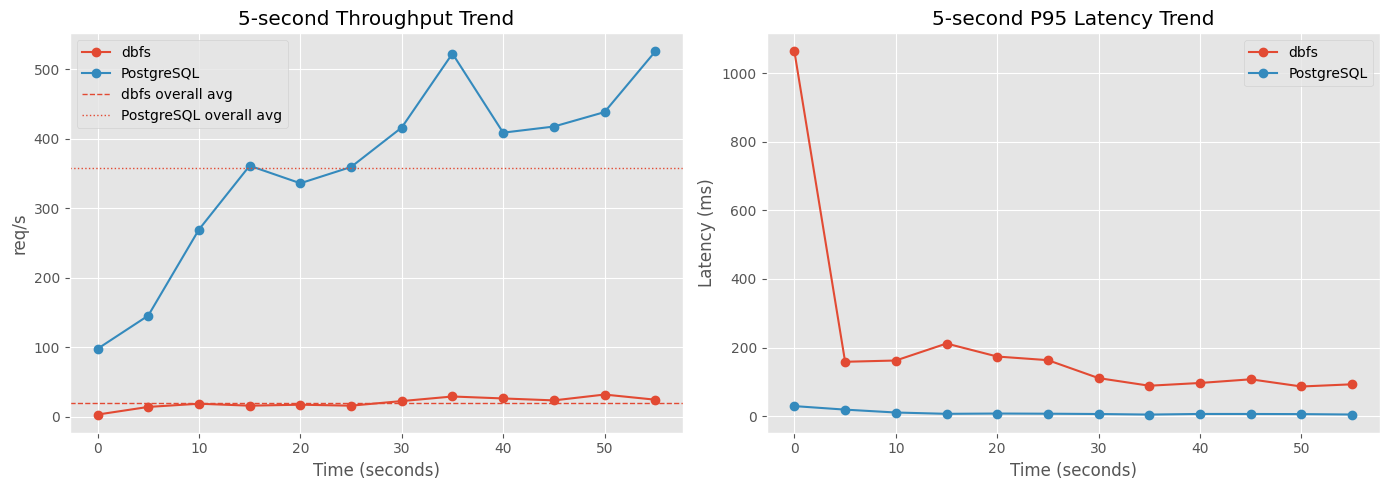

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for engine, run in runs.items():
    results_df = run['results_df']
    label = run['display_name']
    axes[0].plot(
        results_df['Time (seconds)'],
        results_df['Throughput (requests/second)'],
        marker='o',
        label=label,
    )
    axes[1].plot(
        results_df['Time (seconds)'],
        results_df['95th Percentile Latency (millisecond)'],
        marker='o',
        label=label,
    )

axes[0].axhline(
    summary_comparison_df.loc['dbfs', 'Throughput (req/s)'],
    linestyle='--',
    linewidth=1,
    label='dbfs overall avg',
)
axes[0].axhline(
    summary_comparison_df.loc['PostgreSQL', 'Throughput (req/s)'],
    linestyle=':',
    linewidth=1,
    label='PostgreSQL overall avg',
)
axes[0].set_title('5-second Throughput Trend')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('req/s')
axes[0].legend()

axes[1].set_title('5-second P95 Latency Trend')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Latency (ms)')
axes[1].legend()

fig.tight_layout()
plt.show()

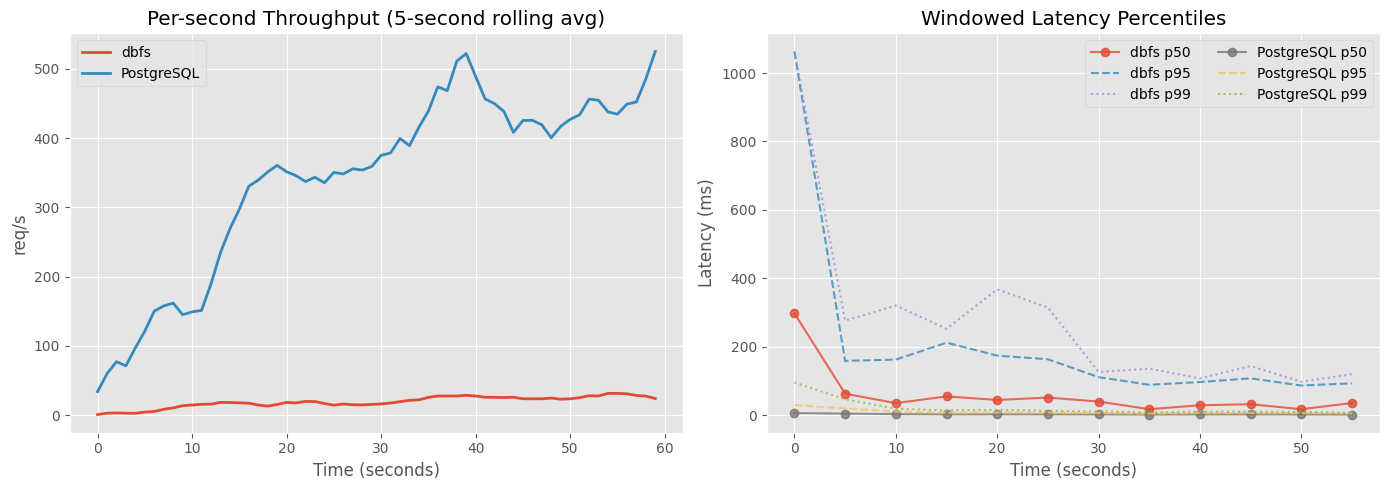

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for engine, run in runs.items():
    samples_df = run['samples_df'].copy()
    results_df = run['results_df']
    label = run['display_name']
    samples_df['Throughput Rolling'] = samples_df[
        'Throughput (requests/second)'].rolling(5, min_periods=1).mean()

    axes[0].plot(
        samples_df['Time (seconds)'],
        samples_df['Throughput Rolling'],
        linewidth=2,
        label=label,
    )
    axes[1].plot(
        results_df['Time (seconds)'],
        results_df['Median Latency (millisecond)'],
        marker='o',
        alpha=0.8,
        label=f'{label} p50',
    )
    axes[1].plot(
        results_df['Time (seconds)'],
        results_df['95th Percentile Latency (millisecond)'],
        linestyle='--',
        alpha=0.8,
        label=f'{label} p95',
    )
    axes[1].plot(
        results_df['Time (seconds)'],
        results_df['99th Percentile Latency (millisecond)'],
        linestyle=':',
        alpha=0.8,
        label=f'{label} p99',
    )

axes[0].set_title('Per-second Throughput (5-second rolling avg)')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('req/s')
axes[0].legend()

axes[1].set_title('Windowed Latency Percentiles')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Latency (ms)')
axes[1].legend(ncol=2)

fig.tight_layout()
plt.show()

,Engine,Procedure,Avg Throughput (req/s),Avg Latency (ms),Avg P95 Latency (ms)
5,PostgreSQL,Delivery,13.733,11.071,22.321
0,dbfs,Delivery,0.967,156.228,202.390
6,PostgreSQL,NewOrder,161.017,4.693,10.005
1,dbfs,NewOrder,8.800,101.461,191.650
7,PostgreSQL,OrderStatus,14.433,2.231,7.825
2,dbfs,OrderStatus,0.917,21.583,27.013
8,PostgreSQL,Payment,154.767,1.885,4.378
3,dbfs,Payment,8.283,50.466,141.029
9,PostgreSQL,StockLevel,13.867,2.183,5.789
4,dbfs,StockLevel,0.967,25.288,32.237


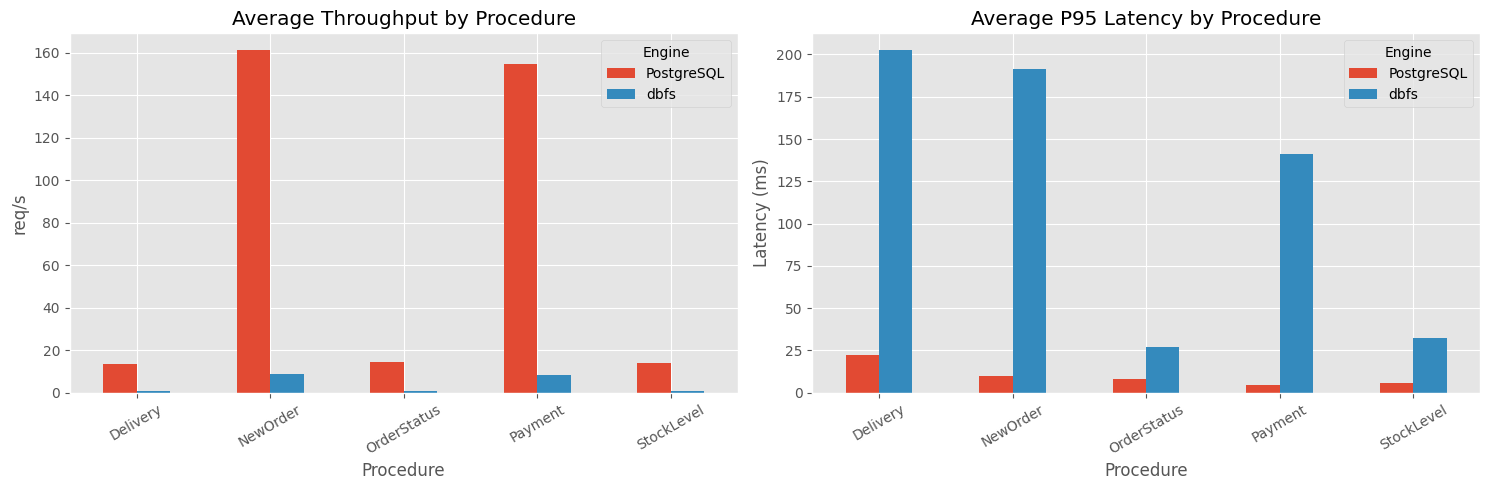

In [9]:
procedure_rows = []
for engine, run in runs.items():
    for procedure_name, procedure_df in run['procedure_dfs'].items():
        procedure_rows.append({
            'Engine':
            run['display_name'],
            'Procedure':
            procedure_name,
            'Avg Throughput (req/s)':
            procedure_df['Throughput (requests/second)'].mean(),
            'Avg Latency (ms)':
            procedure_df['Average Latency (millisecond)'].mean(),
            'Avg P95 Latency (ms)':
            procedure_df['95th Percentile Latency (millisecond)'].mean(),
        })

procedure_comparison_df = pd.DataFrame(procedure_rows).sort_values(
    ['Procedure', 'Engine'])
display(procedure_comparison_df)

procedure_throughput = procedure_comparison_df.pivot(
    index='Procedure', columns='Engine', values='Avg Throughput (req/s)')
procedure_p95 = procedure_comparison_df.pivot(index='Procedure',
                                              columns='Engine',
                                              values='Avg P95 Latency (ms)')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
procedure_throughput.plot(kind='bar', ax=axes[0])
axes[0].set_title('Average Throughput by Procedure')
axes[0].set_ylabel('req/s')
axes[0].tick_params(axis='x', rotation=30)

procedure_p95.plot(kind='bar', ax=axes[1])
axes[1].set_title('Average P95 Latency by Procedure')
axes[1].set_ylabel('Latency (ms)')
axes[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

In [10]:
mix_comparison_rows = []
for engine in transaction_mix_df['Engine'].unique():
    engine_mix = transaction_mix_df[transaction_mix_df['Engine'] ==
                                    engine].set_index('Transaction')
    for transaction_name, configured_ratio in configured_ratios.items():
        observed_ratio = engine_mix.loc[transaction_name, 'Observed Mix (%)']
        mix_comparison_rows.append({
            'Engine':
            engine,
            'Transaction':
            transaction_name,
            'Configured Ratio (%)':
            configured_ratio,
            'Observed Ratio (%)':
            observed_ratio,
            'Absolute Error (pp)':
            abs(observed_ratio - configured_ratio),
        })

mix_comparison_df = pd.DataFrame(mix_comparison_rows)
display(mix_comparison_df)

report_rows = []
for engine, run in runs.items():
    parsed = parse_terminal_log(run['terminal_log'])
    completed_total = transaction_mix_df.loc[transaction_mix_df['Engine'] ==
                                             run['display_name'],
                                             'Completed'].sum()
    aborted_total = transaction_mix_df.loc[
        transaction_mix_df['Engine'] == run['display_name'], 'Aborted'].sum()

    report_rows.append({
        'run_label':
        run['label'],
        'engine':
        run['display_name'],
        'dbms_type':
        parsed['dbms_type'],
        'workload':
        parsed['workload'],
        'scale_factor':
        float(parsed['scale_factor']),
        'terminals':
        int(parsed['terminals']),
        'duration_seconds':
        run['summary']['Elapsed Time (nanoseconds)'] / 1_000_000_000,
        'measured_requests':
        run['summary']['Measured Requests'],
        'throughput_req_per_s':
        run['summary']['Throughput (requests/second)'],
        'goodput_req_per_s':
        run['summary']['Goodput (requests/second)'],
        'completed_transactions':
        int(completed_total),
        'aborted_transactions':
        int(aborted_total),
        'abort_percentage':
        (aborted_total / (completed_total + aborted_total) * 100) if
        (completed_total + aborted_total) else 0.0,
    })

report_df = pd.DataFrame(report_rows)
display(report_df)

,Engine,Transaction,Configured Ratio (%),Observed Ratio (%),Absolute Error (pp)
0,dbfs,NewOrder,45.000,0.000,45.000
1,dbfs,Payment,43.000,0.000,43.000
2,dbfs,OrderStatus,4.000,0.000,4.000
3,dbfs,Delivery,4.000,0.000,4.000
4,dbfs,StockLevel,4.000,0.000,4.000
5,PostgreSQL,NewOrder,45.000,0.000,45.000
6,PostgreSQL,Payment,43.000,0.000,43.000
7,PostgreSQL,OrderStatus,4.000,0.000,4.000
8,PostgreSQL,Delivery,4.000,0.000,4.000
9,PostgreSQL,StockLevel,4.000,0.000,4.000


,run_label,engine,dbms_type,workload,scale_factor,terminals,duration_seconds,measured_requests,throughput_req_per_s,goodput_req_per_s,completed_transactions,aborted_transactions,abort_percentage
0,tpcc_2026-06-03_06-05-15,dbfs,POSTGRES,TPCC,1.000,1,60.000,1196,19.933,19.900,0,0,0.000
1,tpcc_2026-06-03_06-08-24,PostgreSQL,POSTGRES,TPCC,1.000,1,60.000,21469,357.816,355.866,0,0,0.000


Top query shapes for dbfs


,kind,executions,time_share_pct,total_elapsed_ms,mean_elapsed_ms,p95_elapsed_ms,max_elapsed_ms,failures,sample_sql
0,QUERY,5330,19.115,"10,606.688",1.989,<NA>,76.822,0,"SELECT S_QUANTITY, S_DATA, S_DIST_01, S_DIST_0..."
1,QUERY,5333,18.410,"10,215.521",1.915,<NA>,262.683,0,"SELECT I_PRICE, I_NAME , I_DATA FROM item WHER..."
2,UPDATE,5304,12.222,"6,781.967",1.278,<NA>,39.346,0,"UPDATE stock SET S_QUANTITY = 87 , S_YTD = S_Y..."
3,UPDATE,5304,8.774,"4,868.486",0.917,<NA>,126.820,0,"INSERT INTO order_line (OL_O_ID, OL_D_ID, OL_W..."
4,QUERY,335,7.581,"4,206.377",12.556,<NA>,151.149,0,"SELECT C_FIRST, C_MIDDLE, C_ID, C_STREET_1, C_..."
5,QUERY,580,3.100,"1,719.955",2.965,<NA>,75.057,0,SELECT NO_O_ID FROM new_order WHERE NO_D_ID = ...
6,UPDATE,497,2.352,"1,304.946",2.625,<NA>,643.469,0,UPDATE warehouse SET W_YTD = W_YTD + 929.20001...
7,QUERY,529,2.215,"1,228.892",2.323,<NA>,37.333,0,"SELECT C_DISCOUNT, C_LAST, C_CREDIT FROM custo..."
8,UPDATE,580,2.152,"1,194.305",2.059,<NA>,39.708,0,UPDATE order_line SET OL_DELIVERY_D = '2026-06...
9,QUERY,580,1.991,"1,104.789",1.904,<NA>,23.172,0,SELECT SUM(OL_AMOUNT) AS OL_TOTAL FROM order_l...


Top query shapes for PostgreSQL


,kind,executions,time_share_pct,total_elapsed_ms,mean_elapsed_ms,p95_elapsed_ms,max_elapsed_ms,failures,sample_sql
0,UPDATE,300040,29.433,"17,196.057",0.057,<NA>,1.853,0,"INSERT INTO order_line VALUES (1, 1, 1, 1, 883..."
1,QUERY,96726,11.623,"6,790.868",0.070,<NA>,173.922,0,"SELECT S_QUANTITY, S_DATA, S_DIST_01, S_DIST_0..."
2,QUERY,96844,10.055,"5,874.652",0.060,<NA>,20.204,0,"SELECT I_PRICE, I_NAME , I_DATA FROM item WHER..."
3,UPDATE,95678,4.852,"2,834.855",0.029,<NA>,2.165,0,"INSERT INTO order_line (OL_O_ID, OL_D_ID, OL_W..."
4,UPDATE,100000,4.359,"2,546.830",0.025,<NA>,0.504,0,"INSERT INTO stock VALUES (1, 1, 66, 0.0, 0, 0,..."
5,UPDATE,100000,3.743,"2,186.882",0.021,<NA>,0.847,0,"INSERT INTO item VALUES (1, 'sxvnjhpdqdxvc', 9..."
6,UPDATE,95678,2.985,"1,743.729",0.018,<NA>,0.834,0,"UPDATE stock SET S_QUANTITY = 87 , S_YTD = S_Y..."
7,UPDATE,30000,2.380,"1,390.298",0.046,<NA>,0.648,0,"INSERT INTO customer VALUES (1, 1, 1, 0.100299..."
8,QUERY,832,1.957,"1,143.106",1.373,<NA>,30.782,0,SELECT COUNT(DISTINCT (S_I_ID)) AS STOCK_COUNT...
9,UPDATE,8240,1.798,"1,050.632",0.127,<NA>,10.142,0,UPDATE order_line SET OL_DELIVERY_D = '2026-06...


Shared query shape overlap


,dbfs_shapes,postgres_shapes,shared_shapes,dbfs_only,postgres_only
0,31,69,31,0,38


,kind_dbfs,executions_dbfs,executions_postgres,total_elapsed_ms_dbfs,total_elapsed_ms_postgres,max_elapsed_ms_dbfs,max_elapsed_ms_postgres,sample_sql
0,QUERY,5330,96726,"10,606.688","6,790.868",76.822,173.922,"SELECT S_QUANTITY, S_DATA, S_DIST_01, S_DIST_0..."
1,QUERY,5333,96844,"10,215.521","5,874.652",262.683,20.204,"SELECT I_PRICE, I_NAME , I_DATA FROM item WHER..."
2,UPDATE,5304,95678,"6,781.967","1,743.729",39.346,0.834,"UPDATE stock SET S_QUANTITY = 87 , S_YTD = S_Y..."
3,UPDATE,5304,95678,"4,868.486","2,834.855",126.820,2.165,"INSERT INTO order_line (OL_O_ID, OL_D_ID, OL_W..."
4,QUERY,335,6028,"4,206.377",846.720,151.149,11.718,"SELECT C_FIRST, C_MIDDLE, C_ID, C_STREET_1, C_..."
5,QUERY,580,8240,"1,719.955",600.724,75.057,65.481,SELECT NO_O_ID FROM new_order WHERE NO_D_ID = ...
8,UPDATE,580,8240,"1,194.305","1,050.632",39.708,10.142,UPDATE order_line SET OL_DELIVERY_D = '2026-06...
6,UPDATE,497,9286,"1,304.946",880.456,643.469,43.563,UPDATE warehouse SET W_YTD = W_YTD + 929.20001...
7,QUERY,529,9662,"1,228.892",902.680,37.333,7.520,"SELECT C_DISCOUNT, C_LAST, C_CREDIT FROM custo..."
10,UPDATE,580,8240,"1,048.746",813.961,79.822,7.673,UPDATE customer SET C_BALANCE = C_BALANCE + 39...


/var/folders/fb/ffh7t7rs47jgclbwtxyfr75w0000gn/T/ipykernel_19850/379990782.py:200: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()


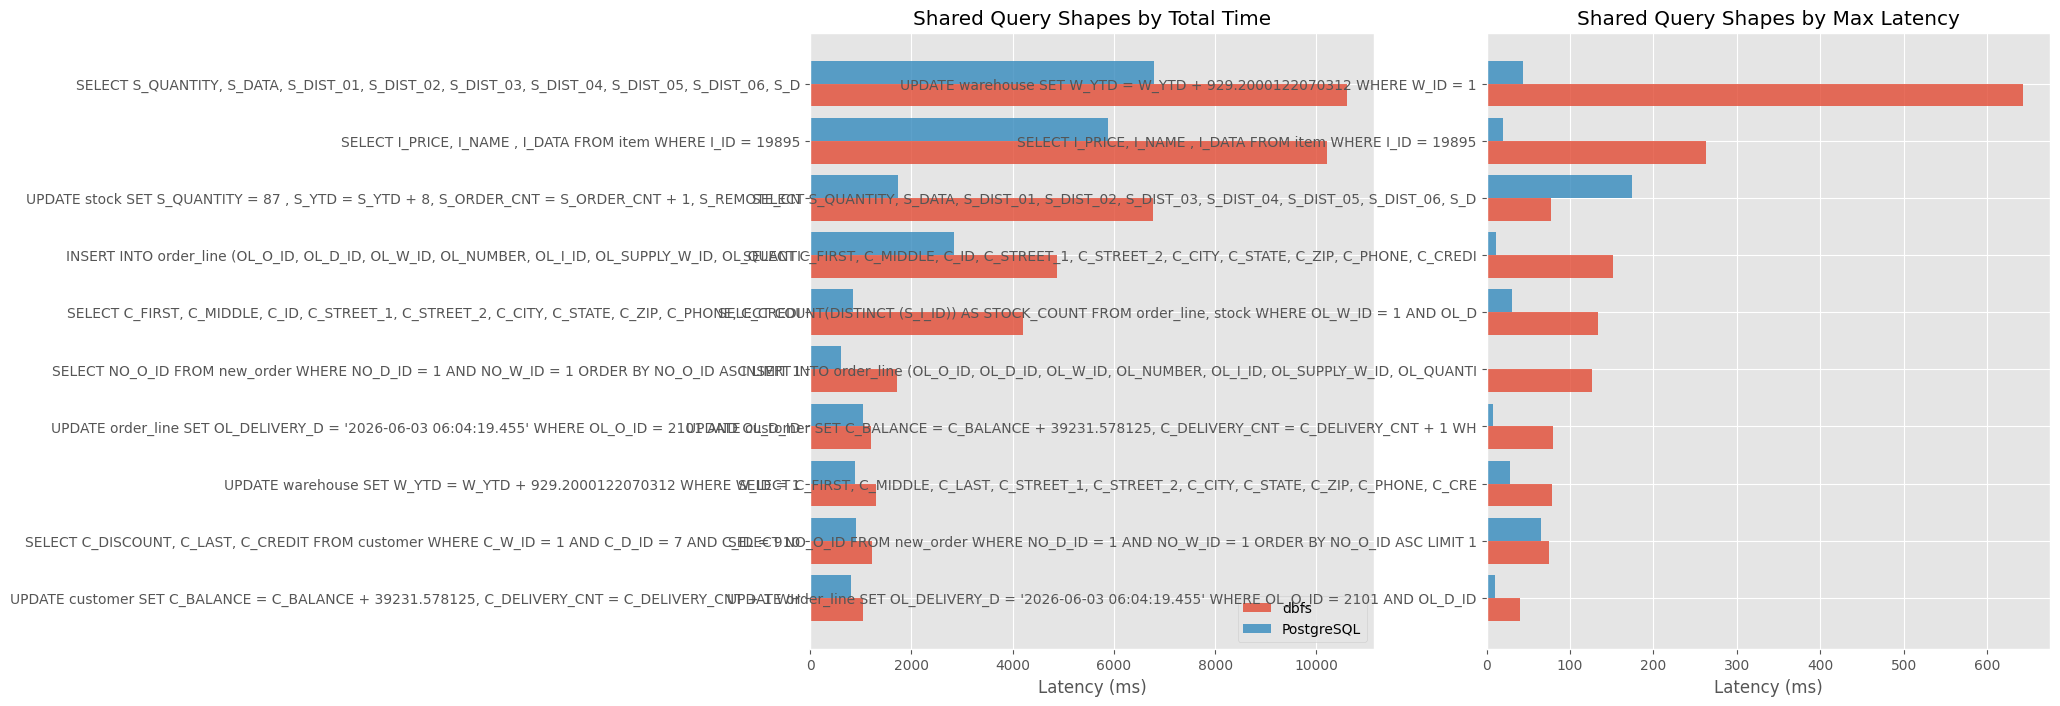

In [11]:
def summarize_dbfs_query_trace(trace_df):
    summary_df = trace_df.copy()
    summary_df['sample_sql'] = summary_df['sample_sql'].fillna(
        summary_df['shape_key'])
    summary_df['total_elapsed_ms'] = summary_df['total_elapsed_us'] / 1000.0
    summary_df['mean_elapsed_ms'] = summary_df['mean_elapsed_us'] / 1000.0
    summary_df['p95_elapsed_ms'] = pd.NA
    summary_df['max_elapsed_ms'] = summary_df['max_elapsed_us'] / 1000.0
    summary_df = summary_df.sort_values(['total_elapsed_ms', 'executions'],
                                        ascending=[False, False])
    return summary_df[[
        'kind',
        'shape_key',
        'sample_sql',
        'executions',
        'total_elapsed_ms',
        'mean_elapsed_ms',
        'p95_elapsed_ms',
        'max_elapsed_ms',
        'failures',
    ]]


def summarize_postgres_server_query_trace(trace_df):
    summary_df = trace_df.copy()
    summary_df['kind'] = 'QUERY'
    summary_df['shape_key'] = summary_df['query'].str.replace(
        r'\s+', ' ', regex=True).str.strip()
    summary_df['sample_sql'] = summary_df['query']
    summary_df['executions'] = summary_df['calls']
    summary_df['total_elapsed_ms'] = summary_df['total_exec_time']
    summary_df['mean_elapsed_ms'] = summary_df['mean_exec_time']
    summary_df['p95_elapsed_ms'] = pd.NA
    summary_df['max_elapsed_ms'] = summary_df['max_exec_time']
    summary_df['failures'] = 0
    summary_df = summary_df.sort_values(['total_elapsed_ms', 'executions'],
                                        ascending=[False, False])
    return summary_df[[
        'kind',
        'shape_key',
        'sample_sql',
        'executions',
        'total_elapsed_ms',
        'mean_elapsed_ms',
        'p95_elapsed_ms',
        'max_elapsed_ms',
        'failures',
    ]]


def summarize_postgres_query_trace(trace_df):
    if {
            'query', 'calls', 'total_exec_time', 'mean_exec_time',
            'max_exec_time'
    }.issubset(trace_df.columns):
        return summarize_postgres_server_query_trace(trace_df)
    return summarize_dbfs_query_trace(trace_df)


def escape_plot_label(text):
    return text.replace('$', r'\$')


def build_shared_trace_comparison(trace_summaries):
    if not {'dbfs', 'postgres'}.issubset(trace_summaries):
        return None

    shared_df = trace_summaries['dbfs'].merge(
        trace_summaries['postgres'],
        on='shape_key',
        how='inner',
        suffixes=('_dbfs', '_postgres'),
    )
    if shared_df.empty:
        return shared_df

    shared_df['sample_sql'] = shared_df['sample_sql_dbfs'].fillna(
        shared_df['sample_sql_postgres'])
    shared_df['combined_total_elapsed_ms'] = (
        shared_df['total_elapsed_ms_dbfs'] +
        shared_df['total_elapsed_ms_postgres'])
    shared_df['combined_max_elapsed_ms'] = shared_df[[
        'max_elapsed_ms_dbfs',
        'max_elapsed_ms_postgres',
    ]].max(axis=1)
    shared_df['label'] = shared_df['sample_sql'].str.slice(0, 96)
    shared_df['plot_label'] = shared_df['label'].map(escape_plot_label)
    return shared_df.sort_values(
        ['combined_total_elapsed_ms', 'combined_max_elapsed_ms'],
        ascending=[False, False],
    )


trace_summaries = {}
for engine, run in runs.items():
    trace_df = run['query_trace_df']
    if trace_df is None or trace_df.empty:
        print(
            f"{run['display_name']}: {query_trace_filenames[engine]} was not found."
        )
        continue

    if engine == 'dbfs':
        engine_summary_df = summarize_dbfs_query_trace(trace_df.copy())
    else:
        engine_summary_df = summarize_postgres_query_trace(trace_df.copy())

    engine_summary_df['Engine'] = run['display_name']
    engine_summary_df['time_share_pct'] = (
        engine_summary_df['total_elapsed_ms'] /
        engine_summary_df['total_elapsed_ms'].sum() * 100)
    engine_summary_df['label'] = engine_summary_df['sample_sql'].str.slice(
        0, 96)
    engine_summary_df['plot_label'] = engine_summary_df['label'].map(
        escape_plot_label)
    trace_summaries[engine] = engine_summary_df

for engine, summary_df in trace_summaries.items():
    display_name = runs[engine]['display_name']
    print(f'Top query shapes for {display_name}')
    display(summary_df[[
        'kind',
        'executions',
        'time_share_pct',
        'total_elapsed_ms',
        'mean_elapsed_ms',
        'p95_elapsed_ms',
        'max_elapsed_ms',
        'failures',
        'sample_sql',
    ]].head(15))

shared_trace_df = build_shared_trace_comparison(trace_summaries)
if shared_trace_df is not None:
    overlap_summary_df = pd.DataFrame([{
        'dbfs_shapes':
        len(trace_summaries['dbfs']),
        'postgres_shapes':
        len(trace_summaries['postgres']),
        'shared_shapes':
        len(shared_trace_df),
        'dbfs_only':
        len(trace_summaries['dbfs']) - len(shared_trace_df),
        'postgres_only':
        len(trace_summaries['postgres']) - len(shared_trace_df),
    }])
    print('Shared query shape overlap')
    display(overlap_summary_df)

    display(shared_trace_df[[
        'kind_dbfs',
        'executions_dbfs',
        'executions_postgres',
        'total_elapsed_ms_dbfs',
        'total_elapsed_ms_postgres',
        'max_elapsed_ms_dbfs',
        'max_elapsed_ms_postgres',
        'sample_sql',
    ]].head(15))

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    plot_specs = [
        (
            'combined_total_elapsed_ms',
            'total_elapsed_ms',
            'Shared Query Shapes by Total Time',
        ),
        (
            'combined_max_elapsed_ms',
            'max_elapsed_ms',
            'Shared Query Shapes by Max Latency',
        ),
    ]

    for axis, (combined_metric, metric, title) in zip(axes, plot_specs):
        top_df = shared_trace_df.nlargest(
            10, combined_metric).sort_values(combined_metric)
        positions = list(range(len(top_df)))
        axis.barh(
            [position - 0.2 for position in positions],
            top_df[f'{metric}_dbfs'],
            height=0.4,
            label='dbfs',
            alpha=0.8,
        )
        axis.barh(
            [position + 0.2 for position in positions],
            top_df[f'{metric}_postgres'],
            height=0.4,
            label='PostgreSQL',
            alpha=0.8,
        )
        axis.set_yticks(positions)
        axis.set_yticklabels(top_df['plot_label'])
        axis.set_title(title)
        axis.set_xlabel('Latency (ms)')

    axes[0].legend()
    fig.tight_layout()
    plt.show()

## Comparison Notes

Conclusion template:

- PostgreSQL shows a large throughput advantage over dbfs under the same TPCC configuration.
- dbfs completed the same workload shape without unexpected SQL errors, which means the current SQL support is sufficient for this TPCC slice.
- The main next step is performance-oriented investigation: loader behavior, per-procedure latency spikes, and the gap between dbfs and PostgreSQL throughput.
- If `dbfs_query_trace.csv` and `postgres_query_trace.csv` are present in the result directories, the notebook also ranks query shapes by total time, mean latency, and max latency to highlight bottlenecks on each engine.